**Example A**

*   We are going to use 2 layers.
optimizer we are going to use SGD.
*   We are going to use without Normalization

**Example B:**
We are going to use 3 layers

*   optimizer we are going to use Adam
*   without normalization

**Example C:**
We are going to use 2 layers

*   optimizer we are going to use SGD
*   We are going to use with Normalization and standardizatio








In [ ]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import MinMaxScaler,OneHotEncoder

In [ ]:
insurance_data=pd.read_csv('/content/sample_data/insurance_data.csv')
insurance_data.head(10)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160


In [ ]:
insurance_data_one_hot=pd.get_dummies(insurance_data)
insurance_data_one_hot.head(10)
#

,age,bmi,children,charges,sex_female,sex_male,smoker_no,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,True,False,False,True,False,False,True
1,18,33.770,1,1725.55230,False,True,True,False,False,True,False
2,28,33.000,3,4449.46200,False,True,True,False,False,True,False
3,33,22.705,0,21984.47061,False,True,True,False,True,False,False
4,32,28.880,0,3866.85520,False,True,True,False,True,False,False
5,31,25.740,0,3756.62160,True,False,True,False,False,True,False


In [ ]:
X=insurance_data_one_hot.drop('charges',axis=1)
y=insurance_data_one_hot['charges']
#

In [ ]:
print('Features')
X.head()

Features


,age,bmi,children,sex_female,sex_male,smoker_no,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,True,False,False,True,False,False,True
1,18,33.770,1,False,True,True,False,False,True,False
2,28,33.000,3,False,True,True,False,False,True,False
3,33,22.705,0,False,True,True,False,True,False,False
4,32,28.880,0,False,True,True,False,True,False,False


In [ ]:
print('Charges')
y.head()

Charges


,charges
0,16884.92400
1,1725.55230
2,4449.46200
3,21984.47061
4,3866.85520


In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
tf.random.set_seed(42)
insurance_model=tf.keras.Sequential([
    tf.keras.layers.Dense(1),
    tf.keras.layers.Dense(1)
])

In [ ]:
insurance_model.compile(loss=tf.keras.losses.mae,
                      optimizer=tf.keras.optimizers.SGD(),
                      metrics=['mae'])

In [ ]:
insurance_model.fit(X_train,y_train,epochs=100)


Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 560ms/step - loss: 8515.2188 - mae: 8515.2188
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 8512.9053 - mae: 8512.9053
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 8510.3711 - mae: 8510.3711
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 8506.0156 - mae: 8506.0156
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 8497.5459 - mae: 8497.5459
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 8480.6709 - mae: 8480.6709
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 8446.9043 - mae: 8446.9043
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 8379.2773 - mae: 8379.2773
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 8243.8145 - mae: 8243.8145
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 7972.4521 - mae: 7972.4521
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 7428.8433 - mae: 7428.8433
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 633

In [ ]:
insurance_model.evaluate(X_test,y_test)
#

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step - loss: 7727.7710 - mae: 7727.7710


[7727.77099609375, 7727.77099609375]

Example B

In [ ]:
tf.random.set_seed(42)
insurance_model_2=tf.keras.Sequential([
    tf.keras.layers.Dense(100),
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
])

insurance_model_2.compile(loss=tf.keras.losses.mae,
                      optimizer=tf.keras.optimizers.Adam(),
                      metrics=['mae'])
insurance_model_2.fit(X_train,y_train,epochs=100)
history_model2=insurance_model_2.fit(X_train,y_train,epochs=150,verbose=0)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 8516.5508 - mae: 8516.5508
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - loss: 8514.5117 - mae: 8514.5117
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 8512.4766 - mae: 8512.4766
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 8510.4414 - mae: 8510.4414
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 8508.4062 - mae: 8508.4062
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 8506.3682 - mae: 8506.3682
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 8504.3232 - mae: 8504.3232
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 8502.2695 - mae: 8502.2695
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 8500.2061 - mae: 8500.2061
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 8498.1289 - mae: 8498.1289
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 8496.0371 - mae: 8496.0371
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 8493.

In [ ]:
insurance_model_2.evaluate(X_test,y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 698ms/step - loss: 7824.3506 - mae: 7824.3506


[7824.3505859375, 7824.3505859375]

In [ ]:
insurance_model_2_loss,insurance_model_2_mae=insurance_model_2.evaluate(X_test,y_test)
print("Loss:",insurance_model_2_loss)
print("MAE:",insurance_model_2_mae)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 7824.3506 - mae: 7824.3506
Loss: 7824.3505859375
MAE: 7824.3505859375


Text(0.5, 1.0, 'Loss vs Epochs')

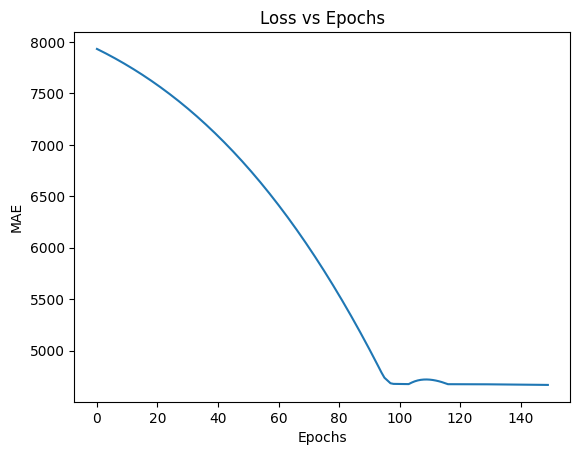

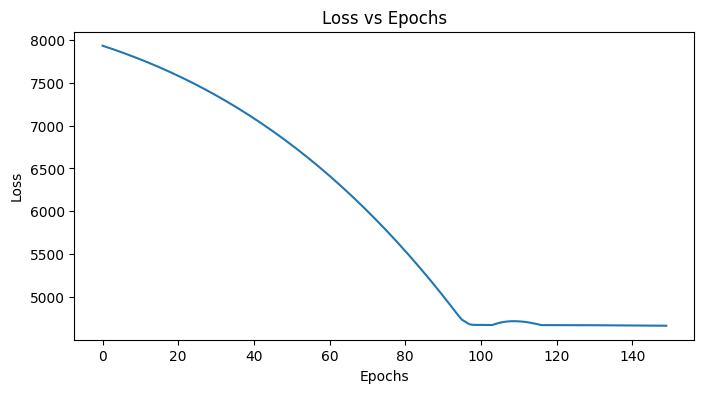

In [ ]:
plt.plot(history_model2.history['loss'])
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.title('Loss vs Epochs')

plt.figure(figsize=(8,4))
plt.plot(history_model2.history['loss'])
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss vs Epochs')

Exercise C

In [ ]:
insurance_data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
ct=make_column_transformer(
    (MinMaxScaler(),["age","bmi","children"]),
    (OneHotEncoder(handle_unknown='ignore'),["sex","smoker","region"])
)

In [ ]:
X=insurance_data.drop('charges',axis=1)
y=insurance_data['charges']
#

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
ct.fit(X_train)

ColumnTransformer(transformers=[('minmaxscaler', MinMaxScaler(),
                                 ['age', 'bmi', 'children']),
                                ('onehotencoder',
                                 OneHotEncoder(handle_unknown='ignore'),
                                 ['sex', 'smoker', 'region'])])

In [ ]:
X_train_normal=ct.transform(X_train)
X_test_normal=ct.transform(X_test)

In [ ]:
X_train

,age,sex,bmi,children,smoker,region
5,31,female,25.740,0,no,southeast
2,28,male,33.000,3,no,southeast
4,32,male,28.880,0,no,northwest
3,33,male,22.705,0,no,northwest


In [ ]:
X_train_normal

array([[0.6       , 0.2948033 , 0.        , 1.        , 0.        ,
        1.        , 0.        , 1.        ],
       [0.        , 1.        , 1.        , 0.        , 1.        ,
        1.        , 0.        , 1.        ],
       [0.8       , 0.59980573, 0.        , 0.        , 1.        ,
        1.        , 1.        , 0.        ],
       [1.        , 0.        , 0.        , 0.        , 1.        ,
        1.        , 1.        , 0.        ]])

In [ ]:
#Normalized data

In [ ]:
print("X-Train",X_train.shape)
print("X-Train-Normal",X_train_normal.shape)

X-Train (4, 6)
X-Train-Normal (4, 8)


In [ ]:
tf.random.set_seed(42)
model3=tf.keras.Sequential([
    tf.keras.layers.Dense(100),
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
])

model3.compile(loss=tf.keras.losses.mae,
                      optimizer=tf.keras.optimizers.Adam(),
                      metrics=['mae'])
model3_history=model3.fit(X_train_normal,y_train,epochs=200,verbose=0)

In [ ]:
model3.evaluate(X_test_normal,y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step - loss: 9165.7939 - mae: 9165.7939


[9165.7939453125, 9165.7939453125]